#INFORMACIÓN GENERAL

UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO

ESCUELA PROFESIONAL DE INGENIERÍA INFORMÁTICA Y DE SISTEMAS

INTELIGENCIA ARTIFICIAL

LABORATORIO 05: ALGORITMOS GENÉTICOS

##MARCO TEÓRICO

Los Algoritmos Genéticos (AGs) son métodos adaptativos que pueden usarse para resolver problemas de búsqueda  y optimización. Están basados en el proceso genético de los organismos vivos. A lo largo de las generaciones, las poblaciones evolucionan en la naturaleza de acorde con los principios de la selección natural y la supervivencia de los más fuertes, postulados por Darwin (1859). Por imitación de este proceso, los Algoritmos Genéticos son capaces de ir creando soluciones para problemas del mundo real.

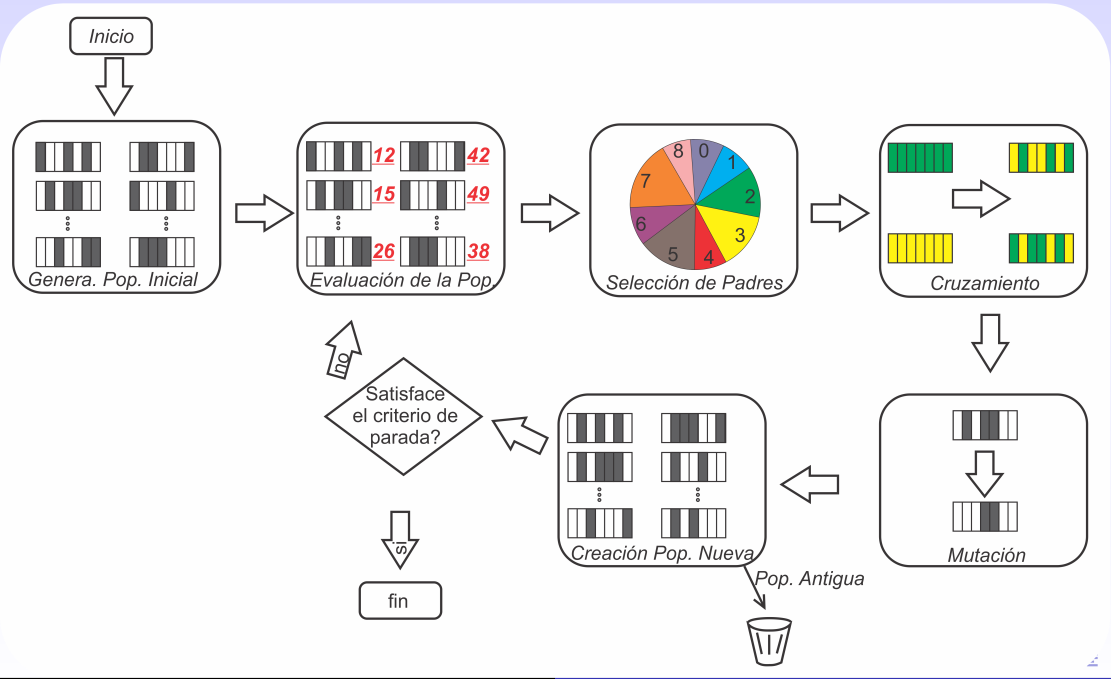
Cortesía del Mgt. Ray Dueñas.

##INSTALACIÓN DE LA LIBRERÍA pyeasyga

CONCEPTOS PREVIOS:

**El Python Package Index o PyPI**.- Es el repositorio de software oficial para aplicaciones de terceros en el lenguaje de programación Python. Los desarrolladores de Python pretenden que sea un catálogo exhaustivo de todos los paquetes de Python escritos en código abierto.

**Package Installer for Python (PIP)**.- Es un sistema de gestión de paquetes utilizado para instalar y administrar paquetes de software escritos en Python. Muchos paquetes pueden ser encontrados en el Python Package Index (PyPI).

**Instalación de paquetes en colab**.- Se efectúa mediante el siguiente comando:

    !pip install nombre_paquete

Los paquetes del repositorio oficial PyPI, se instalan mediante el comando anterior.

**pyeasyga**.- Una implementación simple y fácil de usar de una librería de algoritmos genéticos en Python.


In [1]:
!pip install pyeasyga

  Preparing metadata (setup.py) ... done
  Created wheel for pyeasyga: filename=pyeasyga-0.3.1-py2.py3-none-any.whl size=6784 sha256=9e829bb5216ddc1d5fc88387c1b0ecba256ac31bc15745d0afe60d2ef63fbd52
  Stored in directory: /root/.cache/pip/wheels/39/f5/58/adaa699f0f3173392da566dff8739993195ba97af97475c20b
Successfully built pyeasyga


##Ejemplo básico de uso de la librería: Problema de la mochila

El problema de la mochila (conocido también como Knapsack Problem o simplemente KP) es un problema de optimización combinatoria: dado un conjunto de artículos, cada uno con un peso y un valor, determinar el número de cada artículo para incluir en una colección de modo que el peso total sea menor o igual a un límite dado y el valor total es lo más grande posible. Deriva su nombre del problema al que se enfrenta alguien que está limitado por una mochila de tamaño fijo y debe llenarla con los artículos más valiosos. El problema surge a menudo en la asignación de recursos, donde los responsables de la toma de decisiones tienen que elegir entre un conjunto de proyectos o tareas no divisibles con un presupuesto fijo o una limitación de tiempo, respectivamente.

In [2]:
from pyeasyga import pyeasyga

# -- Configurar los datos
data = [{'name': 'box1', 'value': 4, 'weight': 12},
        {'name': 'box2', 'value': 2, 'weight': 1},
        {'name': 'box3', 'value': 10, 'weight': 4},
        {'name': 'box4', 'value': 1, 'weight': 1},
        {'name': 'box5', 'value': 2, 'weight': 2}]

# -- Crear el objeto de algoritmos genéticos de la librería pyeasyga
ga = pyeasyga.GeneticAlgorithm(data)

# -- Definir la función de aptitud
def FnAptitud(individual, data):
    values, weights = 0, 0
    for selected, box in zip(individual, data):
      if selected:
          values += box.get('value')
          weights += box.get('weight')
    if weights > 15:
        values = 0
    return values

# -- Asignar al objeto la función de aptitud
ga.fitness_function = FnAptitud
# -- Ejecutar el algoritmo genético
ga.run()
# -- Mostrar el mejor resultado
#    El primer valor corresponde al de la función de aptitud del mejor indidividuo
#    El segundo valor (la lista) corresponde a la configuración del mejor individuo
print(ga.best_individual())

(15, [0, 1, 1, 1, 1])


##Clase de problemas de algoritmos genéticos

Esta clase generaliza la solución mediante algoritmos genéticos de problemas que tienen un patrón de comportamiento similar. En este caso, problemas con cromosomas que tienen genes con valores distintos; es decir, no hay dos genes que tengan el mismo valor.  

In [3]:
import random
from pyeasyga import pyeasyga

# -- Clase problemas de Algoritmos Geneticos con caso especial de cruce y mutación
class ProblemaAG:
  # -- Constructor
  def __init__(self, nombre, individuo, nroIndividuos, FnAptitud):
    self.nombre = nombre
    self.individuo = individuo
    self.nroIndividuos = nroIndividuos
    self.FnAptitud = FnAptitud

  # -- Nombre
  def __str__(self):
    return self.nombre

  # -- Crear individuo
  def FnIndividuo(self, individuo):
      individuoNuevo = individuo[:]
      random.shuffle(individuoNuevo)
      return individuoNuevo

  # -- Función de selección
  def FnSeleccion(self, poblacion):
      return random.choice(poblacion)

  # -- Función de cruce
  def FnCruce(self, padre1, padre2):
    # -- Determinar aleatoriamente el índice para el cruce
    indiceCruce = random.randrange(1, len(padre1))
    hijo1 = padre1[:indiceCruce] + [i for i in padre2 if i not in padre1[:indiceCruce]]
    hijo2 = padre2[:indiceCruce] + [i for i in padre1 if i not in padre2[:indiceCruce]]
    # print(hijo1,hijo2)
    return hijo1, hijo2

  # -- Función de mutación
  def FnMutacion(self, individuo):
    # -- Se intercambia los genes de las posiciones dadas por los índices
    indice1 = random.randrange(len(individuo))
    indice2 = random.randrange(len(individuo))
    individuo[indice1], individuo[indice2] = individuo[indice2], individuo[indice1]

  # -- Ejecutar algoritmo genético
  def Ejecutar(self):
    ga = pyeasyga.GeneticAlgorithm( self.individuo,
                                    population_size=self.nroIndividuos,
                                    generations=100,
                                    crossover_probability=0.8,
                                    mutation_probability=0.2,
                                    elitism=True,
                                    maximise_fitness=False)

    # -- Asignar lógica de crear individuos al algoritmo genético
    ga.create_individual = self.FnIndividuo
    # -- Asignar función de aptitud
    ga.fitness_function = self.FnAptitud
    # -- Asignar función de Selección
    ga.selection_function = self.FnSeleccion
    # -- Asignar función de curce (crossover)
    ga.crossover_function = self.FnCruce
    # -- Asignar función de mutación
    ga.mutate_function = self.FnMutacion

    # -- Ejecutar el algoritmo genético
    ga.run()

    # -- Devolver resultado
    return ga.best_individual()


##Problema de las 8 reinas

Este problema consiste en colocar, sobre un tablero de ajedrez, ocho reinas sin que ninguna de ellas amenace a otra.

Es muy probable que cuando en 1848 el ajedrecista alemán Max Bezzel concibió el problema de las ocho reinas, no se imaginara las vueltas que su planteamiento daría.

In [4]:
import random
from pyeasyga import pyeasyga

# -- Clase del problema de las 8 reinas
class Problema8Reinas:
  # -- Constructor
  def __init__(self):
    self.nombre = 'Problema de las 8 reinas'
    self.individuo = [0,1,2,3,4,5,6,7]
    self.nroIndividuos = 200

  # -- Texto asociado a la clase
  def __str__(self):
    return self.nombre

  # -- Definir la función de aptitud del algoritmo genético
  def FnAptitud(self, individuo, individuoPatron):
     # -- Inicializar  número de colisiones
    nroAtaques = 0
    # -- Determinar el número de reinas que se atacan entre sí (colisiones)
    for i in range(0,len(individuo)):
      # -- Determinar la fila en la que está la reina
      f = individuo[i]
      # -- Se verificará sólo sobre las diagonales de (i,f); para lo cual
      #    se incrementará siempre i; mientras que f se decrementará e incrementará en 1
      incremento = 1
      for k in range(i+1,len(individuo)):
        # -- Se verifica con la casilla de la diagonal superior y diagonal inferior
        if (individuo[k] == f-incremento) or (individuo[k] == f+incremento):
          nroAtaques += 1
        incremento += 1
    return nroAtaques

  # -- Mostrar mejor solución
  def MostrarSolucion(self, solucion):
    # -- Imprimir el mejor individuo
    print(solucion)
    # -- Imprimir la parte superior del tablero con códigos ASCII
    print('┌───┬───┬───┬───┬───┬───┬───┬───┐')
    for k in range(0, 8):
      # -- Imprimir cada fila, ubicando la reina en la respectiva columna
      TextoLinea = '│'
      for c in range(0,8):
        TextoLinea += ' '+('R' if solucion[1][c]==k else ' ')+' │'
      print(TextoLinea)
      # -- Imprimir las líneas intermedias o la parte final del tablero
      if k < 7:
        print('├───┼───┼───┼───┼───┼───┼───┼───┤')
      else:
        print('└───┴───┴───┴───┴───┴───┴───┴───┘')

  # -- Ejecutar algoritmo genético
  def Ejecutar(self):
    # -- Crear objeto del problema de las 8 reinas
    p8r = ProblemaAG('Problema de las 8 reinas',self.individuo,self.nroIndividuos,self.FnAptitud)
    # -- Ejecutar problema de algoritmo genético
    mejorIndividuo = p8r.Ejecutar()
    # -- Mostrar el mejor resultado
    if mejorIndividuo[0] == 0:
      print('Se encontró solución ¡¡¡ ÓPTIMA  !!!')
      self.MostrarSolucion(mejorIndividuo)
    else:
      print('No se encontró solución...')
      print('Hay ',mejorIndividuo[0],' colisiones')
      self.MostrarSolucion(mejorIndividuo)


In [5]:
# PROGRAMA PRINCIPAL
# -- Crear objeto del problema de las 8 reinas
p8r = Problema8Reinas()
p8r.Ejecutar()

Se encontró solución ¡¡¡ ÓPTIMA  !!!
(0, [5, 1, 6, 0, 3, 7, 4, 2])
┌───┬───┬───┬───┬───┬───┬───┬───┐
│   │   │   │ R │   │   │   │   │
├───┼───┼───┼───┼───┼───┼───┼───┤
│   │ R │   │   │   │   │   │   │
├───┼───┼───┼───┼───┼───┼───┼───┤
│   │   │   │   │   │   │   │ R │
├───┼───┼───┼───┼───┼───┼───┼───┤
│   │   │   │   │ R │   │   │   │
├───┼───┼───┼───┼───┼───┼───┼───┤
│   │   │   │   │   │   │ R │   │
├───┼───┼───┼───┼───┼───┼───┼───┤
│ R │   │   │   │   │   │   │   │
├───┼───┼───┼───┼───┼───┼───┼───┤
│   │   │ R │   │   │   │   │   │
├───┼───┼───┼───┼───┼───┼───┼───┤
│   │   │   │   │   │ R │   │   │
└───┴───┴───┴───┴───┴───┴───┴───┘


##Problema del cuadrado mágico

Un cuadrado mágico es una tabla de grado primario donde se dispone de una serie de números enteros en un cuadrado o matriz de forma tal que la suma de los números por columnas, filas y diagonales principales sea la misma. Usualmente los números empleados para rellenar las casillas son consecutivos, de 1 a n², siendo n el número de columnas y filas del cuadrado mágico.

En el siguiente código, se resolverá el cuadrado mágico para n = 3.

In [6]:
import random
from pyeasyga import pyeasyga

# -- Clase de cuadrado mágico
class CuadradoMagico:
  # -- Constructor
  def __init__(self):
    self.nombre = 'Cuadrado mágico 3x3'
    self.individuo = [1,2,3,4,5,6,7,8,9]
    self.nroIndividuos = 300

  # -- Texto asociado a la clase
  def __str__(self):
    return self.nombre

  # -- Definir la función de aptitud del algoritmo genético
  def FnAptitud(self, individuo, individuoPatron):
    # -- Inicializar lista de sumas
    sumas = [0 for i in range(0, 8)]
     # -- Filas
    sumas[0] = individuo[0] + individuo[1] + individuo[2] # -- Fila 1
    sumas[1] = individuo[3] + individuo[4] + individuo[5] # -- Fila 2
    sumas[2] = individuo[6] + individuo[7] + individuo[8] # -- Fila 3

    # -- Columnas
    sumas[3] = individuo[0] + individuo[3] + individuo[6] # -- Columna 1
    sumas[4] = individuo[1] + individuo[4] + individuo[7] # -- Columna 2
    sumas[5] = individuo[2] + individuo[5] + individuo[8] # -- Columna 3

    # -- Diagonales
    sumas[6] = individuo[0] + individuo[4] + individuo[8] # -- Diagonal 1
    sumas[7] = individuo[2] + individuo[4] + individuo[6] # -- Diagonal 2

    # -- Determinar cuántas sumas son diferentes de 15. Es óptimo cuando todas las sumas son 15
    return len([s for s in sumas if s != 15])
  # -- Mostrar mejor solución
  def MostrarSolucion(self, solucion):
    valores = list(solucion[1])
    for i in range(0, len(valores)):
      if (i % 3 == 0):
        print('\n')
      print(valores[i], ' ', end="")

  # -- Ejecutar algoritmo genético
  def Ejecutar(self):
    # -- Crear objeto de problema de alogritmo Genético
    pga = ProblemaAG('Cuadrado Mágico 3x3',self.individuo,self.nroIndividuos,self.FnAptitud)
    # -- Ejecutar problema de algoritmo genético
    mejorIndividuo = pga.Ejecutar()
    # -- Mostrar el mejor resultado
    if mejorIndividuo[0] == 0:
      print('Se encontró solución ¡¡¡ ÓPTIMA  !!!')
      self.MostrarSolucion(mejorIndividuo)
    else:
      print('No se encontró solución...')
      print('Hay ',mejorIndividuo[0],' filas/columnas/diagonales no óptimas')
      self.MostrarSolucion(mejorIndividuo)


In [7]:
# PROGRAMA PRINCIPAL

# -- Crear objeto de cuadrado mágico 3x3
pcm = CuadradoMagico()
pcm.Ejecutar()

No se encontró solución...
Hay  1  filas/columnas/diagonales no óptimas


5  7  3  

9  2  4  

1  6  8  

##Ejercicios propuestos

1.- Implementar una clase Cuadrado Mágico nxn (para n >= 3 y <=10), en base a la clase de Cuadrado Mágico de 3x3.

2.- Implementar la solución completa con algoritmos genéticos al problema de las 8 reinas; es decir, sin utilizar ninguna librería de algoritmos genéticos.